# Imports and Read CSV File

In [1]:

import numpy as np
import pandas as pd
from pandas import read_csv

In [2]:
df = read_csv('../data/BTC-USD/BTC-USD_from_2010-01-01_till_2026-01-03.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


# Understand The Data

In [3]:
df.tail()

,Date,Close,High,Low,Open,Volume
4121,2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
4122,2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
4123,2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
4124,2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
4125,2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


In [4]:
df.shape

(4126, 6)

## Setting Date as Index

In [5]:
# Set Date as index for time series analysis

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


In [6]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


# Applying ML Models

In [7]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


## Random Forest

In [8]:
df_random_forest = df.copy()

In [9]:
df_random_forest.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


### Defining Features and Targets

In [10]:
# Create lag features
def create_lags(df, column='Close', lags=5):
    df = df.copy()
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df[column].shift(lag)
    df['target'] = df[column].shift(-1)  # Predict next day
    return df.dropna()


# Apply
df_features = create_lags(df_random_forest, 'Close', lags=5)
X = df_features.drop(['target'], axis=1, errors='ignore')
y = df_features['target']

### Test-Train Split

In [11]:
# # Time series split (80/20)
# split_idx = int(len(X) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# dates_test = df_features.index[split_idx:]

# print(f"Train: {len(X_train)}, Test: {len(X_test)}")

In [12]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

y_true_all = []
y_pred_all = []
dates_all = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_true_all.extend(y_test.values)
    y_pred_all.extend(y_pred)
    dates_all.extend(X_test.index)

NameError: name 'model' is not defined

### Model Training

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model trained ✓")

### Prediction and Plot

In [ ]:
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

mae = mean_absolute_error(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_all, y_pred_all)
mape = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_pct_avg = (rmse / y_true_all.mean()) * 100

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"RMSE % of Avg: {rmse_pct_avg:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(dates_all, y_true_all, label='Actual', linewidth=2)
plt.plot(dates_all, y_pred_all, '--', label='Predicted', linewidth=2)

plt.title('Random Forest Walk-Forward Predictions vs Actual', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Forecast Prediction

In [ ]:
# Forecast horizon
n_days = 365

# Start forecast from the next day after last observation
start_date = df.index[-1] + pd.Timedelta(days=1)

future_dates = pd.date_range(
    start=start_date,
    periods=n_days,
    freq='D'
)

# Predict next 365 days
next_prices = predict_next_days(
    model,
    last_row,
    days=n_days
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Historical prices
plt.plot(df.index, df['Close'], label='Historical', linewidth=1.5)

# Forecast
plt.plot(
    future_dates,
    next_prices,
    label='365-Day Forecast',
    linewidth=2,
    color='red'
)

# Highlight forecast period
plt.axvspan(
    future_dates[0],
    future_dates[-1],
    alpha=0.15,
    color='red'
)

# Last observed date marker
plt.axvline(
    df.index[-1],
    linestyle='--',
    alpha=0.7,
    label='Last Observed Date'
)

plt.title('Price History with 365-Day Forecast',
          fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ARIMA

In [ ]:
df_arima = df.copy()
df_arima.tail()

In [ ]:
%matplotlib inline
# Add grid for better readability
df_arima['Close'].plot(
    figsize=(14, 6), title='Original Close Price (df)', color='blue', grid=True)

# Add axis labels
ax = df_arima['Close'].plot(
    figsize=(14, 6), title='Original Close Price (df)', color='blue')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')

# Show the plot (if not in Jupyter)
plt.show()

### Apply Transformation

In [ ]:
df_transformed = df.copy()

df_transformed = np.log1p(df_transformed)  # Log transformation
df_transformed['Close'].plot(
    figsize=(14, 6), title='Transformed Close Price (df_transformed)', color='green', grid=True)

### Spliting the Dataset

In [ ]:
train_size = len(df_transformed['Close']) - 30
df_train = df_transformed['Close'].iloc[:train_size]
df_test = df_transformed['Close'].iloc[train_size:]

In [ ]:
df_train.shape, df_test.shape

### PCF and PACF Plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assuming df_transformed is your DataFrame
# Let's extract the Close price series
close_series = df_transformed['Close']

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot ACF (Autocorrelation Function)
plot_acf(close_series, lags=40,
         ax=axes[0], title='Autocorrelation Function (ACF) - Close Price')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

# Plot PACF (Partial Autocorrelation Function)
plot_pacf(close_series, lags=40,
          ax=axes[1], title='Partial Autocorrelation Function (PACF) - Close Price')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

### ADF Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
result = adfuller(df_transformed['Close'])

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.6f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")

# Conclusion
if result[1] <= 0.05:
    print("\n✅ Series is STATIONARY (reject null hypothesis)")
else:
    print("\n❌ Series is NON-STATIONARY (fail to reject null hypothesis)")

### Transforming to Stationary: Differencing

In [ ]:
# First difference
df_diff = df_train.diff()

# Drop NaN from first row
df_diff = df_diff.dropna()

print(f"Original shape: {df_train.shape}")
print(f"Differenced shape: {df_diff.shape}")

# Quick check
print("\nFirst 5 values:")
print(df_diff.head())
df_diff.plot(
    figsize=(14, 6), title='First Difference of Transformed Close Price', color='orange', grid=True)

### Applying PCF and PACF Plot to Differenced Data

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Check stationarity of differenced series
adf_result = adfuller(df_diff)
p_value = adf_result[1]

# Create plots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
plot_acf(df_diff, lags=40, ax=axes[0],
         title=f'ACF Plot - First Differenced Close Price (p={p_value:.6f})')

# PACF Plot
plot_pacf(df_diff, lags=40, ax=axes[1],
          title=f'PACF Plot - First Differenced Close Price (p={p_value:.6f})')

plt.tight_layout()
plt.show()

print(f"\nDifferenced Series ADF p-value: {p_value:.6f}")
print(f"Stationary: {'YES' if p_value <= 0.05 else 'NO'}")

### Determine ARIMA Model's Parameters p, q

In [ ]:
# ARIMA 0, 1, 0 model (Random Walk with drift)
# The first difference removed all predictable patterns
# Daily price changes appear random (uncorrelated with past changes)


from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Assuming you've already split the data
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

# Apply ARIMA(0,1,0) based on our analysis
print("\nFitting ARIMA(0,1,0) model...")
model = ARIMA(df_train, order=(0, 1, 0))
model_fit = model.fit()

print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(model_fit.summary())

### Plotting Residual and Density Plot

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Get residuals from the fitted model
residuals = model_fit.resid

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(residuals.index, residuals, color='red', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuals Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram with KDE
axes[0, 1].hist(residuals, bins=30, density=True, alpha=0.7,
                color='skyblue', edgecolor='black')
sns.kdeplot(residuals, ax=axes[0, 1], color='darkred', linewidth=2)
axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residual Distribution with KDE',
                     fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_marker('o')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[0].set_alpha(0.7)
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].get_lines()[1].set_linewidth(2)
axes[1, 0].set_title('Q-Q Plot (Normality Check)',
                     fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF of residuals (to check for remaining autocorrelation)
plot_acf(residuals, lags=40, ax=axes[1, 1], title='ACF of Residuals')
axes[1, 1].set_title('ACF of Residuals', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical tests for residuals
print("="*60)
print("RESIDUAL DIAGNOSTICS")
print("="*60)

# Normality test
shapiro_stat, shapiro_p = shapiro(residuals.dropna())
jb_stat, jb_p = jarque_bera(residuals.dropna())

print(f"\n1. Normality Tests:")
print(
    f"   Shapiro-Wilk test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")
print(f"   Jarque-Bera test: statistic={jb_stat:.4f}, p-value={jb_p:.6f}")
print(f"   Normal distribution? {'YES' if shapiro_p > 0.05 else 'NO'}")

# Zero mean test
mean_resid = residuals.mean()
std_resid = residuals.std()
print(f"\n2. Mean and Std Deviation:")
print(f"   Mean of residuals: {mean_resid:.6f} (should be ~0)")
print(f"   Std of residuals: {std_resid:.6f}")

# Ljung-Box test for autocorrelation
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"\n3. Ljung-Box Test (autocorrelation):")
print(f"   p-value at lag 10: {lb_test['lb_pvalue'].iloc[0]:.6f}")
print(
    f"   No autocorrelation? {'YES' if lb_test['lb_pvalue'].iloc[0] > 0.05 else 'NO'}")

print(f"\n4. Residual Summary:")
print(f"   Min: {residuals.min():.4f}")
print(f"   Max: {residuals.max():.4f}")
print(f"   Range: {residuals.max() - residuals.min():.4f}")

### Predicting and Forecasting

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make forecast for the test period
forecast_steps = len(df_test)  # Forecast same length as test set
forecast = model_fit.forecast(steps=forecast_steps)

# Create forecast series with proper index
forecast_index = pd.date_range(
    start=df_train.index[-1], periods=forecast_steps+1, freq='D')[1:]
forecast_series = pd.Series(forecast, index=forecast_index)

print("="*60)
print("FORECAST RESULTS")
print("="*60)
print(
    f"Forecast period: {forecast_series.index[0]} to {forecast_series.index[-1]}")
print(f"Number of forecast steps: {forecast_steps}")
print(f"\nFirst 5 forecast values:")
print(forecast_series.head())
print(f"\nLast 5 forecast values:")
print(forecast_series.tail())

# Calculate forecast accuracy metrics
mae = mean_absolute_error(df_test, forecast_series)
mse = mean_squared_error(df_test, forecast_series)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((df_test - forecast_series) / df_test)) * 100

print("\n" + "="*60)
print("FORECAST ACCURACY METRICS")
print("="*60)
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute % Error (MAPE):   {mape:.2f}%")

# Plot the forecast vs actual
plt.figure(figsize=(14, 8))

# Plot training data (last 100 observations for clarity)
train_plot_len = min(100, len(df_train))
plt.plot(df_train.index[-train_plot_len:], df_train[-train_plot_len:],
         label='Training Data', color='blue', linewidth=2)

# Plot test data
plt.plot(df_test.index, df_test, label='Actual Test Data',
         color='green', linewidth=2)

# Plot forecast
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast',
         color='red', linestyle='--', linewidth=2)

plt.title(
    f'ARIMA(0,1,0) Forecast vs Actual\nMAPE: {mape:.2f}%', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot forecast error
forecast_error = df_test - forecast_series

plt.figure(figsize=(14, 5))
plt.bar(forecast_error.index, forecast_error, alpha=0.7, color='orange')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Forecast Errors (Actual - Forecast)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Error')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Auto Fit ARIMA Model

In [ ]:
import pmdarima as pm
# Super simple auto-ARIMA
auto_model = pm.auto_arima(df_train, seasonal=False, suppress_warnings=True)
forecast = auto_model.predict(n_periods=len(df_test))
print(f"Auto-ARIMA{auto_model.order} forecast complete! MAPE: {np.mean(np.abs((df_test - forecast)/df_test))*100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Chart 1: ARIMA(0,1,0) Model
axes[0].plot(df_train.index[-50:], df_train[-50:],
             label='Training Data', color='blue', linewidth=2, alpha=0.8)
axes[0].plot(df_test.index, df_test,
             label='Actual Test Data', color='green', linewidth=2, alpha=0.8)
axes[0].plot(df_test.index, manual_forecast,
             label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)

axes[0].set_title(f'ARIMA(0,1,0) Forecast vs Actual\nMAPE: {manual_mape:.2f}%',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Close Price', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Auto-ARIMA Model
axes[1].plot(df_train.index[-50:], df_train[-50:],
             label='Training Data', color='blue', linewidth=2, alpha=0.8)
axes[1].plot(df_test.index, df_test,
             label='Actual Test Data', color='green', linewidth=2, alpha=0.8)
axes[1].plot(df_test.index, auto_forecast,
             label=f'Auto-ARIMA{auto_model.order} Forecast',
             color='red', linestyle='--', linewidth=2)

axes[1].set_title(f'Auto-ARIMA{auto_model.order} Forecast vs Actual\nMAPE: {auto_mape:.2f}%',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Close Price', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## LSTM

In [ ]:
df_lstm = df.copy()
df_lstm.tail()

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(df_lstm.index, df_lstm['Close'], color='blue')
plt.show()

### Preprocessing

In [ ]:
import numpy as np
import pandas as pd


def df_to_windowed_df(dataframe, first_date_str, last_date_str, window_size=5):
    """Convert DataFrame to windowed DataFrame for time series analysis."""

    first_date = pd.to_datetime(first_date_str)
    last_date = pd.to_datetime(last_date_str)

    # Filter dataframe by date range
    df_filtered = dataframe.loc[
        (dataframe.index >= first_date) & (dataframe.index <= last_date)
    ].copy()

    # Create lagged features (previous date values)
    for i in range(1, window_size + 1):
        df_filtered[f'Close_lag_{i}'] = df_filtered['Close'].shift(i)

    # Target is the current date's Close value
    df_filtered['Target'] = df_filtered['Close']

    # Drop rows with NaN values created by shifting
    df_windowed = df_filtered.dropna()

    # Reorder columns: Close_lag_5, Close_lag_4, ..., Close_lag_1, Target
    lag_cols = [f'Close_lag_{i}' for i in range(window_size, 0, -1)]
    df_windowed = df_windowed[lag_cols + ['Target']]

    return df_windowed


df_windowed = df_to_windowed_df(df_lstm, '2024-12-31', '2025-12-31', window_size=5)
df_windowed.tail()

In [ ]:
def windowed_df_to_date_X_y(windowed_dataframe):
    """
    Convert windowed DataFrame into dates, X, y arrays.
    Assumes:
    - Index is Date
    - Columns: Close_lag_n ... Close_lag_1, Target
    """

    # Dates come from the index
    dates = windowed_dataframe.index.to_numpy()

    # Convert dataframe to numpy
    df_as_np = windowed_dataframe.to_numpy()

    # X = all lag columns (everything except last column)
    X = df_as_np[:, :-1]

    print(f"X shape before reshape: {X.shape}")

    # Reshape X to (samples, timesteps, features)
    X = X.reshape((len(dates), X.shape[1], 1))

    print(f"X shape after reshape: {X.shape}")
    # y = Target column
    y = df_as_np[:, -1]

    return dates, X.astype(np.float32), y.astype(np.float32)

In [ ]:
dates, X, y = windowed_df_to_date_X_y(df_windowed)
dates.shape, X.shape, y.shape

In [ ]:
df_windowed.shape

### Spliting the Dataset into Train and Test

In [ ]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]


plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val, y_val, label='Validation')
plt.plot(dates_test, y_test, label='Test')
plt.legend()
plt.show()

### Train the Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.optimizers import Adam
from keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


print("\n" + "="*60)
print("DATA SCALING")
print("="*60)

scaler_X = StandardScaler()
scaler_y = StandardScaler()


def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):
    """Scale features and target variables."""

    # Scale X features
    if len(X_train.shape) == 3:
        X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
        X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
        X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

        X_train_scaled = scaler_X.fit_transform(
            X_train_reshaped).reshape(X_train.shape)
        X_val_scaled = scaler_X.transform(X_val_reshaped).reshape(X_val.shape)
        X_test_scaled = scaler_X.transform(
            X_test_reshaped).reshape(X_test.shape)
    else:
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_val_scaled = scaler_X.transform(X_val)
        X_test_scaled = scaler_X.transform(X_test)

    # Scale y target
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled


# Apply scaling
X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled = scale_data(
    X_train, X_val, X_test, y_train, y_val, y_test
)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(
    f"X_train_scaled mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(
    f"y_train_scaled mean: {y_train_scaled.mean():.4f}, std: {y_train_scaled.std():.4f}")

In [ ]:
print("\n" + "="*60)
print("BUILDING LSTM MODEL")
print("="*60)


def build_lstm_model(input_shape=(3, 1)):
    """Build and return an LSTM model."""

    model = Sequential([
        layers.Input(input_shape),
        layers.LSTM(128, return_sequences=True,
                    kernel_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=True,
                    kernel_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.LSTM(32, kernel_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1)
    ])

    optimizer = Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    )

    model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=['mean_absolute_error', 'mean_squared_error']
    )

    return model


# Build model
model = build_lstm_model(input_shape=(
    X_train_scaled.shape[1], X_train_scaled.shape[2]))
print("Model Summary:")
model.summary()

In [ ]:
print("\n" + "="*60)
print("SETTING UP TRAINING CALLBACKS")
print("="*60)


def get_training_callbacks():
    """Create and return training callbacks."""

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=0.00001,
        verbose=1
    )

    return [early_stopping, reduce_lr]


callbacks = get_training_callbacks()
print("Callbacks created: EarlyStopping, ReduceLROnPlateau")

In [ ]:
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining completed after {len(history.history['loss'])} epochs")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

### Make Prediction

In [ ]:
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)


def make_predictions(model, X_train_scaled, X_val_scaled, X_test_scaled):
    """Make predictions on all datasets."""

    train_predictions_scaled = model.predict(
        X_train_scaled, verbose=0).flatten()
    val_predictions_scaled = model.predict(X_val_scaled, verbose=0).flatten()
    test_predictions_scaled = model.predict(X_test_scaled, verbose=0).flatten()

    # Inverse transform to original scale
    train_predictions = scaler_y.inverse_transform(
        train_predictions_scaled.reshape(-1, 1)).flatten()
    val_predictions = scaler_y.inverse_transform(
        val_predictions_scaled.reshape(-1, 1)).flatten()
    test_predictions = scaler_y.inverse_transform(
        test_predictions_scaled.reshape(-1, 1)).flatten()

    return train_predictions, val_predictions, test_predictions


train_predictions, val_predictions, test_predictions = make_predictions(
    model, X_train_scaled, X_val_scaled, X_test_scaled
)

print(f"Predictions made on {len(train_predictions)} training samples")
print(f"Predictions made on {len(val_predictions)} validation samples")
print(f"Predictions made on {len(test_predictions)} test samples")

### Visualization

In [ ]:
print("\n" + "="*60)
print("PLOTTING RESULTS")
print("="*60)


def plot_predictions(dates_train, y_train, train_predictions,
                     dates_val, y_val, val_predictions,
                     dates_test, y_test, test_predictions):
    """Plot predictions vs actual values."""

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot training data
    axes[0].plot(dates_train, y_train, 'b-', label='Training Observations',
                 linewidth=2, alpha=0.7)
    axes[0].plot(dates_train, train_predictions, 'r--',
                 label='Training Predictions', linewidth=2)
    axes[0].set_title('Training Set: Predictions vs Actual', fontsize=14)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Plot validation and test
    axes[1].plot(dates_val, y_val, 'g-', label='Validation Observations',
                 linewidth=2, alpha=0.7)
    axes[1].plot(dates_val, val_predictions, 'm--',
                 label='Validation Predictions', linewidth=2)
    axes[1].plot(dates_test, y_test, 'c-', label='Test Observations',
                 linewidth=2, alpha=0.7)
    axes[1].plot(dates_test, test_predictions, 'y--',
                 label='Test Predictions', linewidth=2)
    axes[1].set_title(
        'Validation & Test Sets: Predictions vs Actual', fontsize=14)
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Value')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return fig


# Create predictions plot
prediction_plot = plot_predictions(
    dates_train, y_train, train_predictions,
    dates_val, y_val, val_predictions,
    dates_test, y_test, test_predictions
)

### Evaluation

In [ ]:
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)


def calculate_metrics(y_true, y_pred, dataset_name):
    """Calculate and display evaluation metrics."""

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Set:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Predictions range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
    print(f"  Actual range: [{y_true.min():.4f}, {y_true.max():.4f}]")

    return {'mse': mse, 'mae': mae, 'rmse': rmse, 'r2': r2}


# Calculate metrics for all datasets
metrics = {}
metrics['train'] = calculate_metrics(y_train, train_predictions, "Training")
metrics['val'] = calculate_metrics(y_val, val_predictions, "Validation")
metrics['test'] = calculate_metrics(y_test, test_predictions, "Test")

# Print summary
print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'MSE':<10} {'MAE':<10} {'RMSE':<10} {'R²':<10}")
print("-"*60)
for dataset in ['train', 'val', 'test']:
    m = metrics[dataset]
    print(
        f"{dataset.capitalize():<15} {m['mse']:<10.4f} {m['mae']:<10.4f} {m['rmse']:<10.4f} {m['r2']:<10.4f}")

## Prophet

### Imports and Visualization

In [13]:
from prophet import Prophet

c:\Users\parth\anaconda3\envs\COM725\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
df_prophet = df.copy()
df_prophet.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


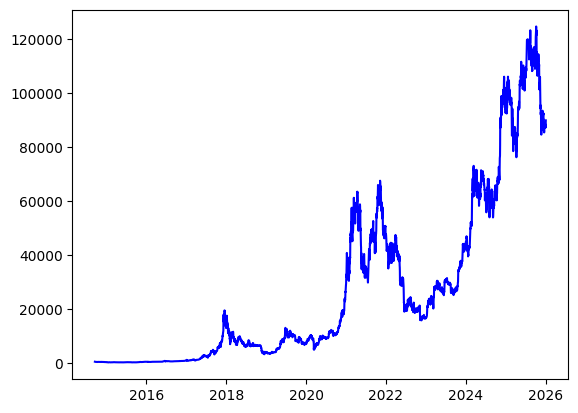

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(df_prophet.index, df_prophet['Close'], color='blue')
plt.show()

### Renaming the Columns

In [16]:
df_prophet["ds"] = pd.to_datetime(df_prophet.index)
df_prophet["y"] = df_prophet["Close"]

df_prophet = df_prophet[["ds", "y"]].sort_values("ds").reset_index(drop=True)

In [17]:
df_prophet.tail()

,ds,y
4121,2025-12-29,87138.140625
4122,2025-12-30,88430.132812
4123,2025-12-31,87508.828125
4124,2026-01-01,88731.984375
4125,2026-01-02,89944.695312


### Training The Model

In [18]:
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True)
prophet.fit(df_prophet)

07:14:58 - cmdstanpy - INFO - Chain [1] start processing
07:14:59 - cmdstanpy - INFO - Chain [1] done processing


### Future Prediction

In [19]:
future = prophet.make_future_dataframe(
    periods=365)  # Forecast 365 days into future
forecast = prophet.predict(future)

### Plot

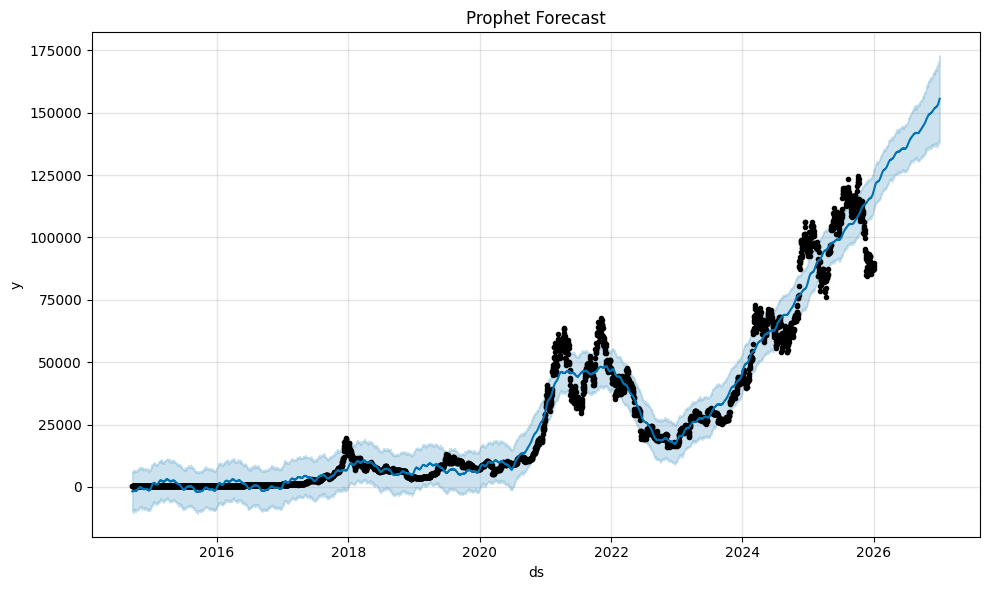

In [20]:
# 5. Plot (matplotlib only - no Plotly)
fig = prophet.plot(forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.show()